# Price-Increase Impact Audit

**Objective:** Estimate whether a fictional 3% price increase introduced in July 2024 had a noticeable effect on monthly buyers from August to December.

The analysis uses seasonally matched pre/post comparisons and an exploratory significance check. It is an indicative commercial audit, not causal proof.

> **Data note:** All monthly values are fictionalized for this public portfolio case study.


## Stage 1 — Define the comparison

I treat **January–June 2024** as the pre-increase period and **August–December 2024** as the post-increase period. July is excluded because customers were informed in mid-July, making it a transition month.

To control for seasonality, I compare each 2024 period with the same months in 2023. I then use the January–June year-over-year buyer change to estimate what August–December 2024 might have looked like without an additional post-July effect.

### Main assumptions

1. Monthly buyer counts are measured consistently across all years.
2. January–June 2024 reflects the underlying change in buyers before the price increase.
3. Comparing the same calendar months helps account for seasonality.
4. No other major event beginning at the same time fully explains the post-July change.
5. Monthly counts represent **buyer-months**, not necessarily unique customers across the whole five-month period.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

buyers = pd.DataFrame({
    2021: [690, 655, 704, 698, 670, 682, 661, 704, 675, 742, 781, 915],
    2022: [650, 628, 679, 668, 619, 632, 614, 598, 657, 721, 683, 792],
    2023: [602, 574, 621, 597, 608, 586, 595, 601, 619, 658, 692, 744],
    2024: [585, 566, 615, 580, 592, 572, 621, 552, 578, 612, 655, 738]
}, index=months)

sales = pd.DataFrame({
    2021: [12834, 12052, 13942, 12680, 12910, 13244, 12420, 13310, 12980, 14125, 15110, 16940],
    2022: [12120, 11780, 13010, 12390, 11940, 12270, 11980, 11610, 12840, 13920, 13410, 14960],
    2023: [11850, 11240, 12420, 11680, 12130, 11960, 12040, 12210, 12680, 13240, 13950, 15120],
    2024: [11990, 11780, 12610, 12020, 12490, 12270, 13750, 12150, 12600, 13210, 14130, 15720]
}, index=months)

assert buyers.shape == (12, 4) and sales.shape == (12, 4)
assert not buyers.isna().any().any() and not sales.isna().any().any()
print('Validation passed: 48 buyer values and 48 sales values; no missing data.')


Validation passed: 48 buyer values and 48 sales values; no missing data.


## Stage 2 — Descriptive comparison and adjusted baseline

First, I compare 2024 with 2023 for the same months. I then adjust the 2023 post-period buyer count by the pre-period year-over-year factor:

$$
\text{Expected post buyers} = \text{2023 post buyers} \times \frac{\text{2024 pre buyers}}{\text{2023 pre buyers}}
$$

This is a simple counterfactual: it assumes that, without an additional post-July effect, the small pre-existing 2024 decline would have continued.

In [2]:
pre_months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
post_months = ['Aug', 'Sep', 'Oct', 'Nov', 'Dec']

pre_2023 = buyers.loc[pre_months, 2023].sum()
pre_2024 = buyers.loc[pre_months, 2024].sum()
post_2023 = buyers.loc[post_months, 2023].sum()
post_2024 = buyers.loc[post_months, 2024].sum()

pre_factor = pre_2024 / pre_2023
expected_post_2024 = post_2023 * pre_factor
estimated_effect = post_2024 - expected_post_2024
estimated_effect_pct = post_2024 / expected_post_2024 - 1

comparison = pd.DataFrame({
    'Measure': [
        'Pre-period buyers (Jan-Jun)',
        'Post-period buyers (Aug-Dec)',
        'Average monthly post buyers'
    ],
    '2023': [pre_2023, post_2023, post_2023 / 5],
    '2024': [pre_2024, post_2024, post_2024 / 5],
    'YoY change': [pre_2024 / pre_2023 - 1, post_2024 / post_2023 - 1, post_2024 / post_2023 - 1]
})
comparison['YoY change'] = comparison['YoY change'].map(lambda x: f'{x:.1%}')
display(comparison)

print(f'Expected Aug-Dec buyer-months: {expected_post_2024:.1f}')
print(f'Actual Aug-Dec buyer-months:   {post_2024:.1f}')
print(f'Estimated shortfall:           {estimated_effect:.1f} buyer-months')
print(f'Average monthly effect:        {estimated_effect / 5:.1f} buyers')
print(f'Estimated percentage effect:   {estimated_effect_pct:.1%}')

                        Measure      2023      2024 YoY change
0   Pre-period buyers (Jan-Jun) 3,588.000 3,510.000      -2.2%
1  Post-period buyers (Aug-Dec) 3,314.000 3,135.000      -5.4%
2   Average monthly post buyers   662.800   627.000      -5.4%
Expected Aug-Dec buyer-months: 3242.0
Actual Aug-Dec buyer-months:   3135.0
Estimated shortfall:           -107.0 buyer-months
Average monthly effect:        -21.4 buyers
Estimated percentage effect:   -3.3%


### Result from Stage 2

- Before the price increase, January–June buyers were **2.2% lower** in 2024 than in 2023.
- After the increase, August–December buyers were **5.4% lower** year over year.
- After allowing for the pre-existing decline, the estimated shortfall is approximately **107 buyer-months**, or **21 fewer buyers per month**.
- This is approximately **3.3% below** the adjusted expectation.


## Stage 3 — Check whether the change looks unusual

I use two simple checks. First, I review the historical August–December averages to see whether buyer counts were already declining. Second, I compare monthly year-over-year percentage changes before and after July with an exploratory Welch t-test.

The test is only supportive: there are just five post-period observations, monthly values may not be fully independent, and there is no untreated control group.

In [3]:
historical_post = pd.Series({
    year: buyers.loc[post_months, year].mean()
    for year in buyers.columns
}, name='Average Aug-Dec buyers')
display(historical_post.round(1).to_frame())

pre_yoy = buyers.loc[pre_months, 2024] / buyers.loc[pre_months, 2023] - 1
post_yoy = buyers.loc[post_months, 2024] / buyers.loc[post_months, 2023] - 1
t_stat, p_value = stats.ttest_ind(post_yoy, pre_yoy, equal_var=False)

print(f'Mean monthly pre-period YoY change:  {pre_yoy.mean():.1%}')
print(f'Mean monthly post-period YoY change: {post_yoy.mean():.1%}')
print(f'Exploratory Welch t-test p-value:    {p_value:.3f}')

      Average Aug-Dec buyers
2021                 763.400
2022                 690.200
2023                 662.800
2024                 627.000
Mean monthly pre-period YoY change:  -2.2%
Mean monthly post-period YoY change: -5.6%
Exploratory Welch t-test p-value:    0.054


### Result from Stage 3

The August–December average fell from **763.4 buyers in 2021** to **690.2 in 2022**, **662.8 in 2023**, and **627.0 in 2024**. The downward pattern therefore began before the price increase.

The exploratory test gives **p ≈ 0.054**, slightly above the conventional `0.05` threshold. I therefore would not describe the result as statistically significant. The small sample, possible serial dependence, and lack of an untreated control are more important limitations than the narrow distance from the threshold.


## Stage 4 — Use sales as supporting context

Sales do not measure buyer response directly, but they help check whether the buyer pattern is commercially plausible.

In [4]:
post_sales_2023 = sales.loc[post_months, 2023].sum()
post_sales_2024 = sales.loc[post_months, 2024].sum()
sales_change = post_sales_2024 / post_sales_2023 - 1

sales_per_buyer_2023 = post_sales_2023 / post_2023
sales_per_buyer_2024 = post_sales_2024 / post_2024
sales_per_buyer_change = sales_per_buyer_2024 / sales_per_buyer_2023 - 1

july_buyer_change = buyers.loc['Jul', 2024] / buyers.loc['Jul', 2023] - 1
july_sales_change = sales.loc['Jul', 2024] / sales.loc['Jul', 2023] - 1

print(f'Aug-Dec sales change:             {sales_change:.1%}')
print(f'2023 Aug-Dec sales per buyer:     ${sales_per_buyer_2023:.2f}')
print(f'2024 Aug-Dec sales per buyer:     ${sales_per_buyer_2024:.2f}')
print(f'Sales per buyer change:           {sales_per_buyer_change:.1%}')
print(f'July buyer change vs July 2023:   {july_buyer_change:.1%}')
print(f'July sales change vs July 2023:   {july_sales_change:.1%}')

Aug-Dec sales change:             0.9%
2023 Aug-Dec sales per buyer:     $20.28
2024 Aug-Dec sales per buyer:     $21.63
Sales per buyer change:           6.7%
July buyer change vs July 2023:   4.4%
July sales change vs July 2023:   14.2%


### Result from Stage 4

August–December sales increased **0.9%** while buyers declined **5.4%**, so sales per buyer rose approximately **6.7%**. This is commercially consistent with higher prices and fewer buyers, but it is not evidence that price alone caused either movement.

July buyers increased **4.4%** and July sales increased **14.2%** year over year. Advance purchasing before the new price took effect is one possible explanation, but it remains a hypothesis.


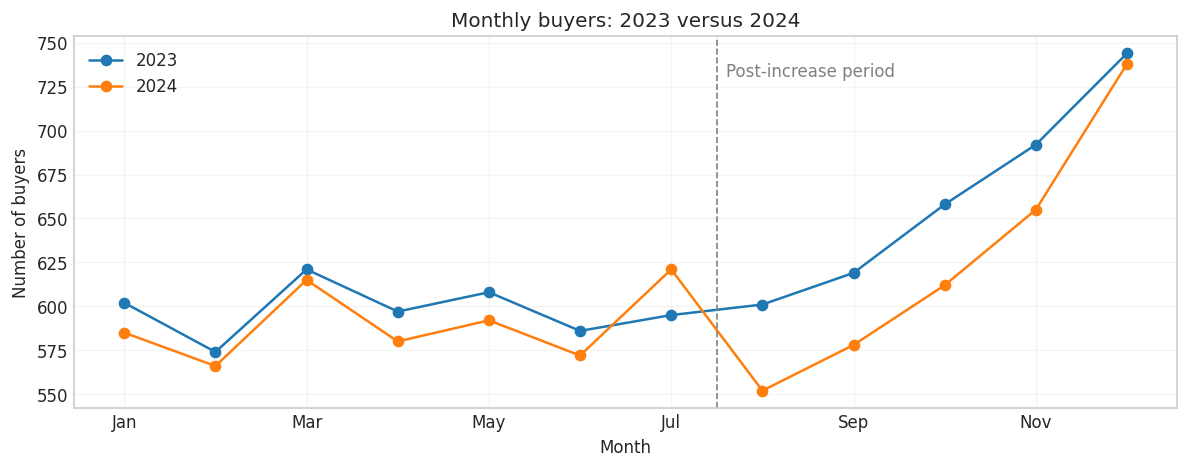

In [5]:
# One concise chart to show seasonality and the change after July.
ax = buyers[[2023, 2024]].plot(marker='o', figsize=(10, 4))
ax.axvline(6.5, color='grey', linestyle='--', linewidth=1)
ax.text(6.6, ax.get_ylim()[1] * 0.98, 'Post-increase period', va='top', color='grey')
ax.set_title('Monthly buyers: 2023 versus 2024')
ax.set_xlabel('Month')
ax.set_ylabel('Number of buyers')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Stage 5 — External and seasonal factors

Factors I would check before attributing the change to price include:

- normal holiday and year-end seasonality;
- promotions, marketing spend, or competitor activity;
- product availability, stock-outs, or assortment changes;
- economic conditions and changes in customer mix;
- whether July communication caused purchases to move forward from August;
- any changes in buyer definitions, tracking, or store operations.

## Stage 6 — Additional data that would strengthen the conclusion

I would request:

1. customer-level transactions to distinguish unique, new, retained, and returning buyers;
2. units, product-level prices, baskets, margins, and purchase frequency;
3. promotion, marketing, stock, competitor, and store-operations data;
4. data from a similar market or store without the price increase;
5. additional months after December 2024 to see whether the decline persisted.

With a credible comparison group, I would next consider a difference-in-differences analysis. With a longer time series, an interrupted time-series model could also be explored.

## Conclusion for leadership

Buyer counts were lower after the fictional July 2024 price increase. From August to December, the business averaged **627.0 buyers per month**, compared with an adjusted expectation of approximately **648.4**. This represents an estimated shortfall of about **21 monthly buyers**, or **3.3%**.

The exploratory test is close to, but does not cross, the conventional 5% significance threshold. Buyer counts were already declining, and there is no untreated control group. Sales remained broadly stable while sales per buyer increased, which is consistent with the pricing change but is not causal proof.

**Overall conclusion:** the data indicates a modest post-increase decline in buyers, but it is insufficient to conclude that the price increase caused a statistically significant change. Customer-level data, a credible comparison market, and a longer post-period would support a stronger decision.
